In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional plotting style
sns.set(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv('dataset/SampleSuperstore.csv')

# Display first 5 rows to understand the structure
print(df.head())

# Check for missing values and data types
print(df.info())

# Basic Descriptive Statistics (Mean, Max, Min for Sales/Profit)
print(df.describe())

        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      0.00    6.871

In [3]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates to ensure accuracy
df.drop_duplicates(inplace=True)

Number of duplicate rows: 17


C:\Users\Abin\AppData\Local\Temp\ipykernel_20188\2921424619.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales.values, palette="viridis")


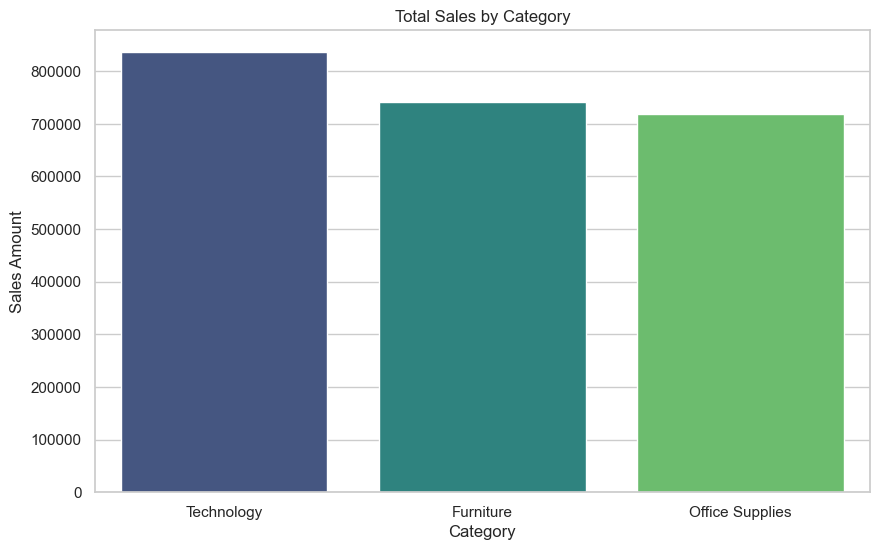

In [4]:
# Group by Category and sum the Sales
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=category_sales.index, y=category_sales.values, palette="viridis")
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales Amount')
plt.savefig('images/sales_by_category.png') # Save for README
plt.show()

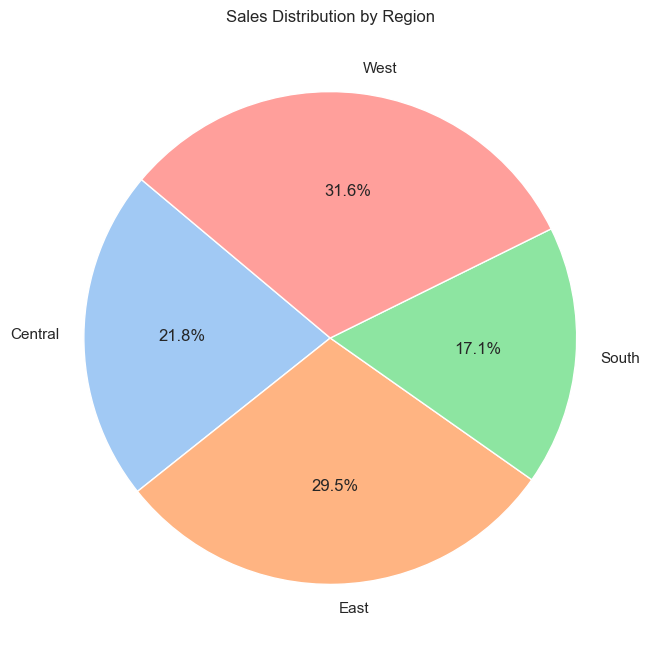

In [5]:
# Group by Region
region_sales = df.groupby('Region')['Sales'].sum()

# Plot
plt.figure(figsize=(8, 8))
plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
plt.title('Sales Distribution by Region')
plt.savefig('images/sales_by_region.png') # Save for README
plt.show()

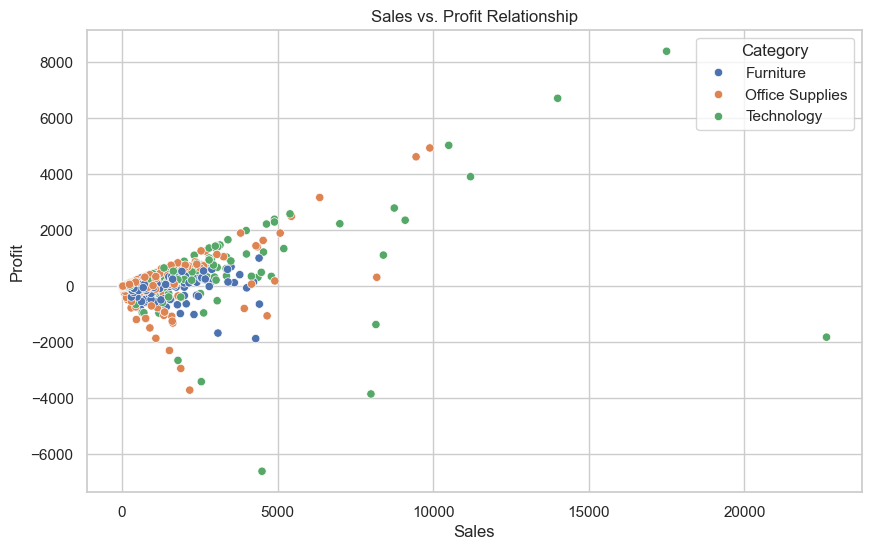

In [6]:
# Scatter plot to see relationship between Sales and Profit
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sales', y='Profit', data=df, hue='Category')
plt.title('Sales vs. Profit Relationship')
plt.savefig('images/sales_vs_profit.png') # Save for README
plt.show()

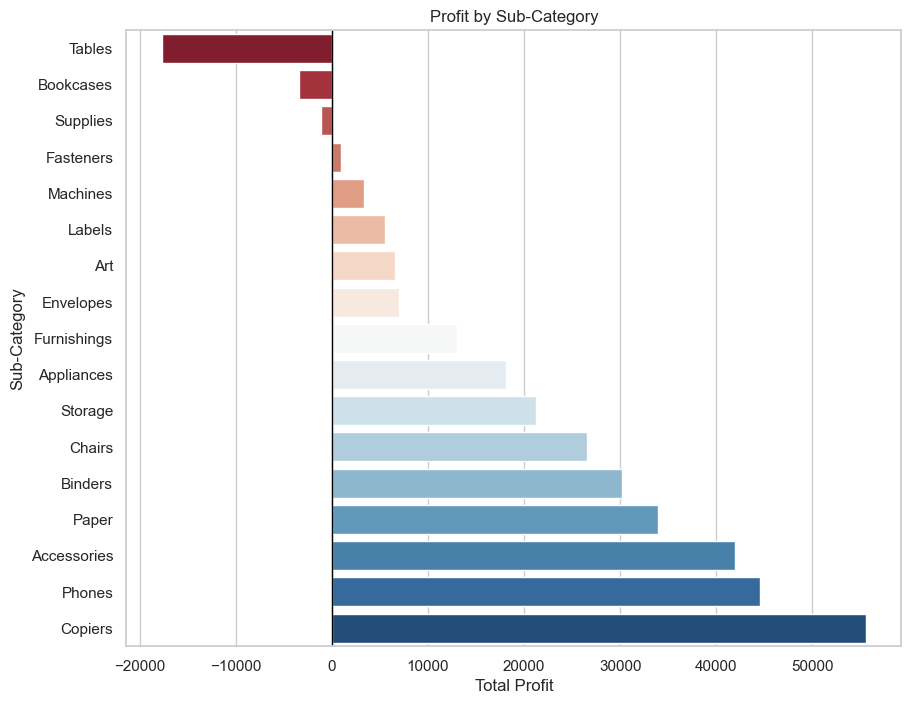

In [8]:
# Group by Sub-Category and sum Profit
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

# Plot
plt.figure(figsize=(10, 8))
# We use 'hue' effectively here by mapping it to the y-axis variable or just using a single color if preferred
sns.barplot(y=subcat_profit.index, x=subcat_profit.values, hue=subcat_profit.index, palette="RdBu", legend=False) 
plt.title('Profit by Sub-Category')
plt.xlabel('Total Profit')
plt.ylabel('Sub-Category')
plt.axvline(x=0, color='black', linewidth=1) # Adds a line at 0 to show losses clearly
plt.savefig('images/profit_by_subcategory.png')
plt.show()

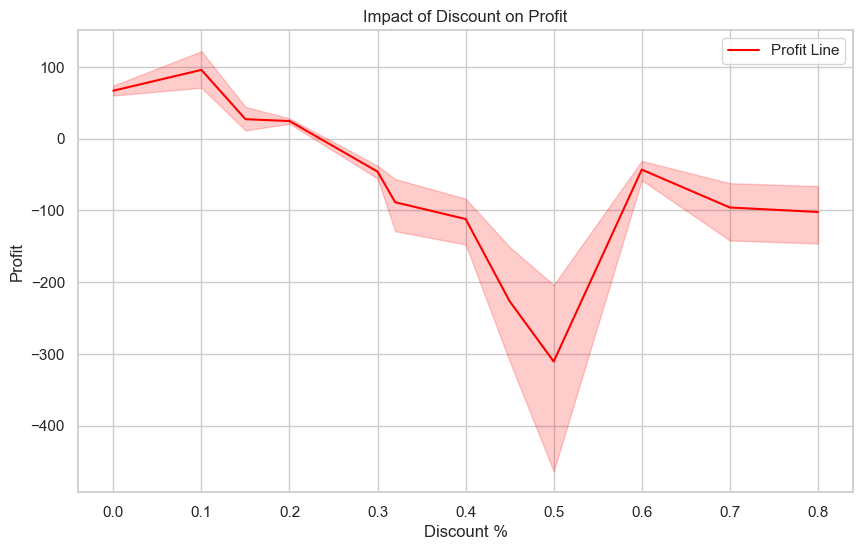

In [9]:
plt.figure(figsize=(10, 6))
sns.lineplot(x='Discount', y='Profit', data=df, label='Profit Line', color='red')
plt.title('Impact of Discount on Profit')
plt.xlabel('Discount %')
plt.ylabel('Profit')
plt.savefig('images/discount_vs_profit.png')
plt.show()

C:\Users\Abin\AppData\Local\Temp\ipykernel_20188\3000441777.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.index, y=state_sales.values, palette="Blues_d")


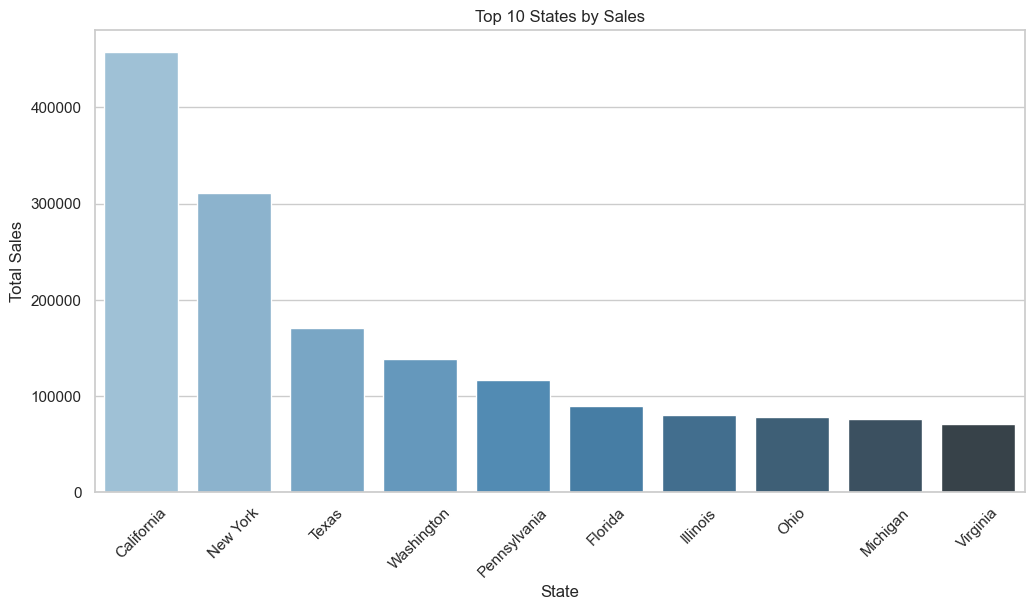

In [10]:
# Group by State and sum Sales
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=state_sales.index, y=state_sales.values, palette="Blues_d")
plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.savefig('images/top_10_states_sales.png')
plt.show()

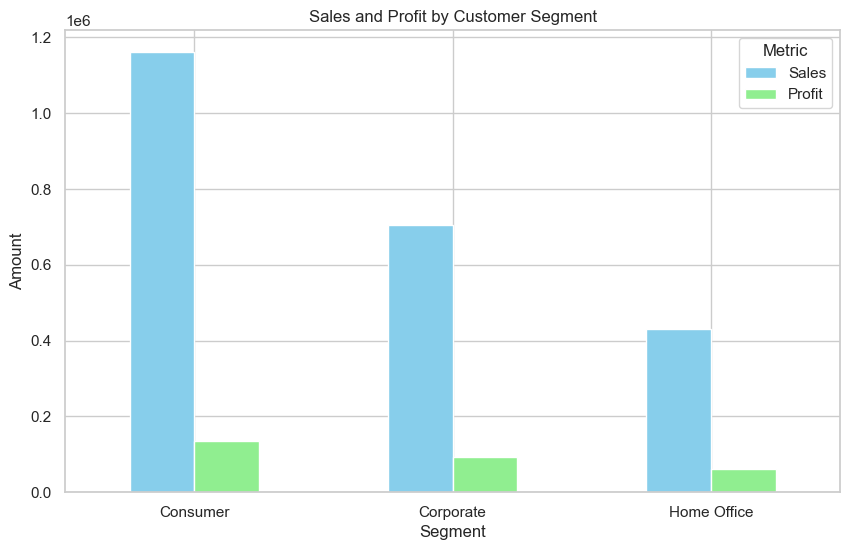

In [11]:
# Group by Segment and sum Sales and Profit
segment_analysis = df.groupby('Segment')[['Sales', 'Profit']].sum()

# Plot
segment_analysis.plot(kind='bar', figsize=(10, 6), color=['skyblue', 'lightgreen'])
plt.title('Sales and Profit by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.savefig('images/segment_analysis.png')
plt.show()

C:\Users\Abin\AppData\Local\Temp\ipykernel_20188\2616416243.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ship_mode_grp.index, y='Profit', data=ship_mode_grp.reset_index(), palette="magma")


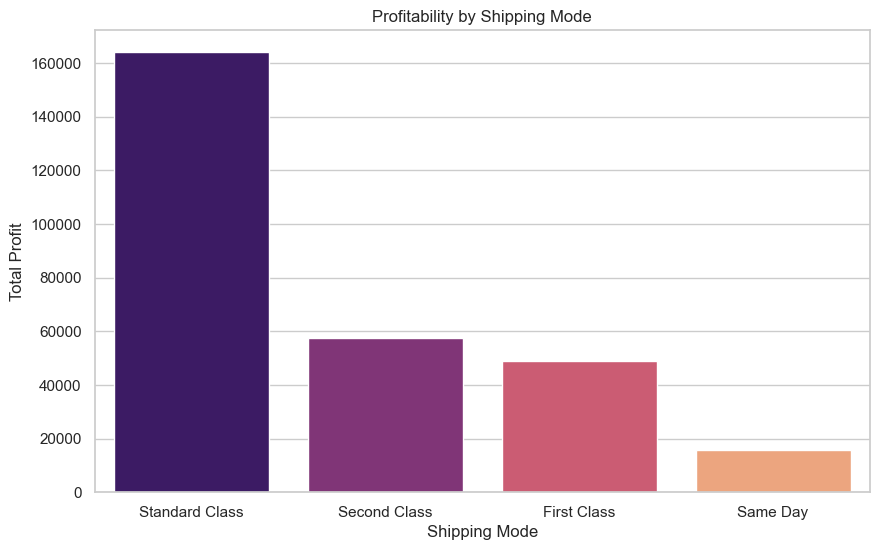

In [12]:
# Group by Ship Mode
ship_mode_grp = df.groupby('Ship Mode')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=ship_mode_grp.index, y='Profit', data=ship_mode_grp.reset_index(), palette="magma")
plt.title('Profitability by Shipping Mode')
plt.xlabel('Shipping Mode')
plt.ylabel('Total Profit')
plt.savefig('images/shipping_mode_profit.png')
plt.show()